##Netflix Dataset Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

 Step 1: Load Dataset

In [2]:
file_path = "/content/Netflix Dataset.csv"
df = pd.read_csv(file_path)

Step 2: Explore Dataset

In [3]:
print("===== Dataset Information =====")
print(df.info())
print("\n===== First 5 Records =====")
print(df.head())

===== Dataset Information =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB
None

===== First 5 Records =====
  Show_Id Category  Title           Director  \
0      s1  TV Show     3%                NaN   
1      s2    Movie  07:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker  

Step 3: Handle Missing Values

In [5]:
print("\n===== Missing Values Before Cleaning =====")
print(df.isnull().sum())
df['Director'] = df['Director'].fillna("Unknown")
df['Cast'] = df['Cast'].fillna("Unknown")
df['Country'] = df['Country'].fillna("Unknown")


===== Missing Values Before Cleaning =====
Show_Id            0
Category           0
Title              0
Director        2388
Cast             718
Country          507
Release_Date      10
Rating             7
Duration           0
Type               0
Description        0
dtype: int64


Step 4: Extract Release Year

In [6]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['Year'] = df['Release_Date'].dt.year

Step 5: Movies vs TV Shows Over the Years

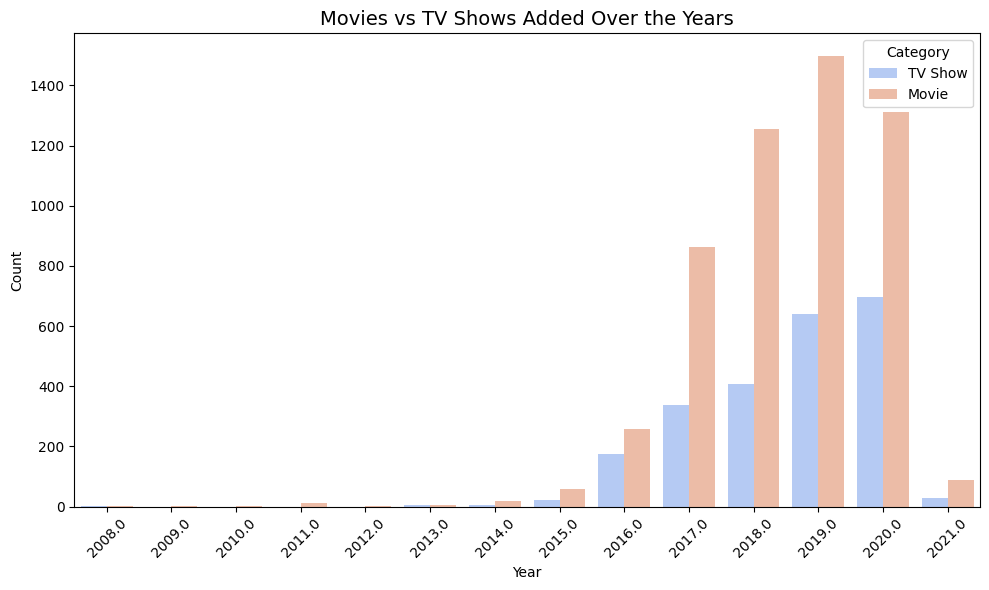

In [7]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Year', hue='Category', palette='coolwarm')
plt.title("Movies vs TV Shows Added Over the Years", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Step 6: Top Contributing Countries

/tmp/ipython-input-449027290.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='magma')


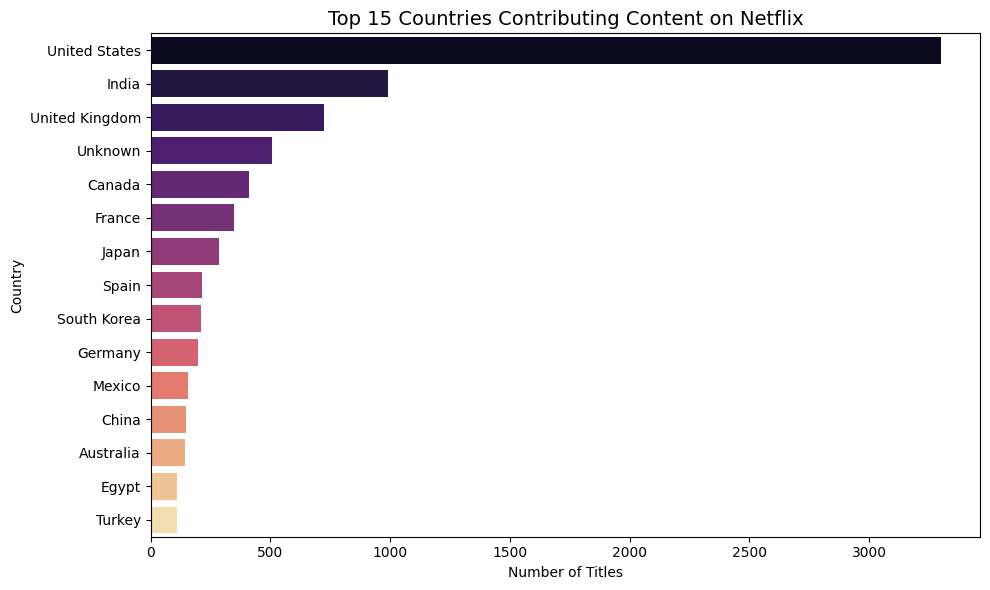

In [8]:
country_data = df['Country'].str.split(',').explode().str.strip()
top_countries = country_data.value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='magma')
plt.title("Top 15 Countries Contributing Content on Netflix", fontsize=14)
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

Step 7: Most Common Ratings

/tmp/ipython-input-3540349824.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Rating', data=df, order=df['Rating'].value_counts().index, palette='viridis')


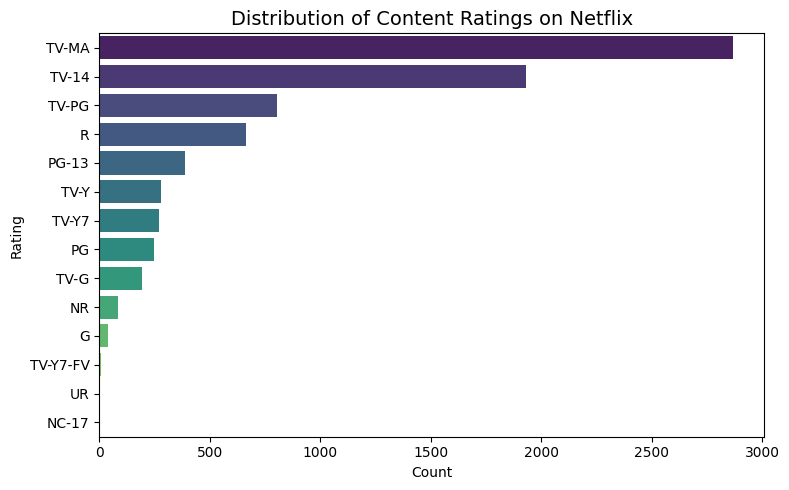

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(y='Rating', data=df, order=df['Rating'].value_counts().index, palette='viridis')
plt.title("Distribution of Content Ratings on Netflix", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

Step 8: Duration Analysis

/tmp/ipython-input-1820000376.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Duration_Type', palette='Set2')


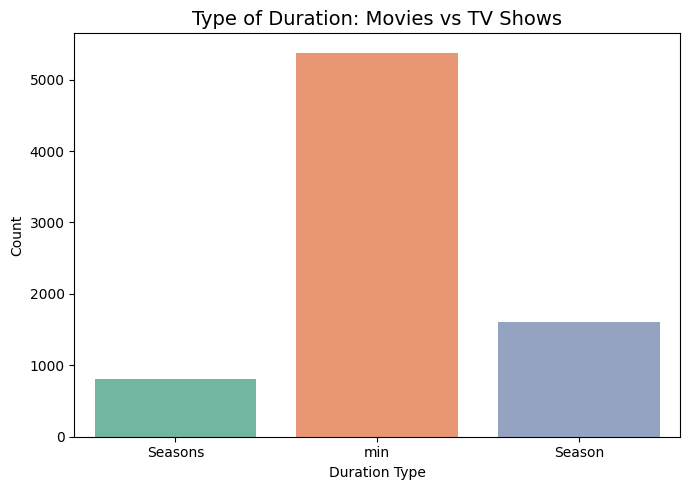

In [10]:
df[['Duration_Val', 'Duration_Type']] = df['Duration'].str.extract(r'(\d+)\s*(\w+)')
df['Duration_Val'] = pd.to_numeric(df['Duration_Val'], errors='coerce')

plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Duration_Type', palette='Set2')
plt.title("Type of Duration: Movies vs TV Shows", fontsize=14)
plt.xlabel("Duration Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Step 9: Top Directors and Casts

/tmp/ipython-input-3466180532.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette='rocket')


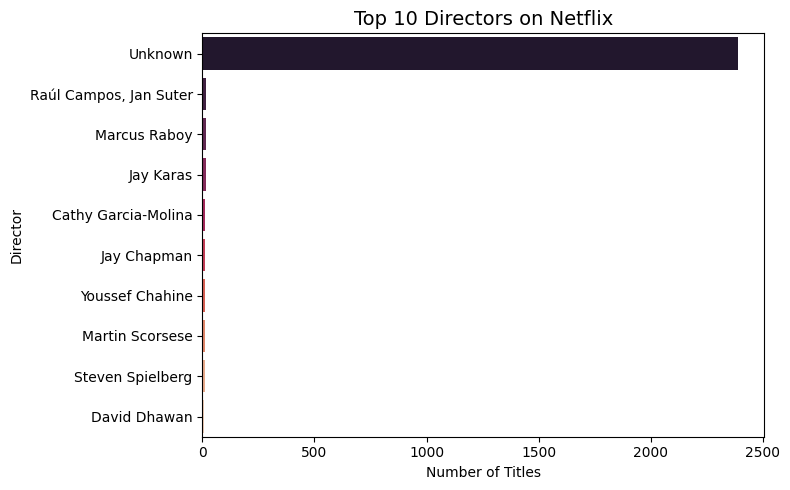

/tmp/ipython-input-3466180532.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cast.values, y=top_cast.index, palette='crest')


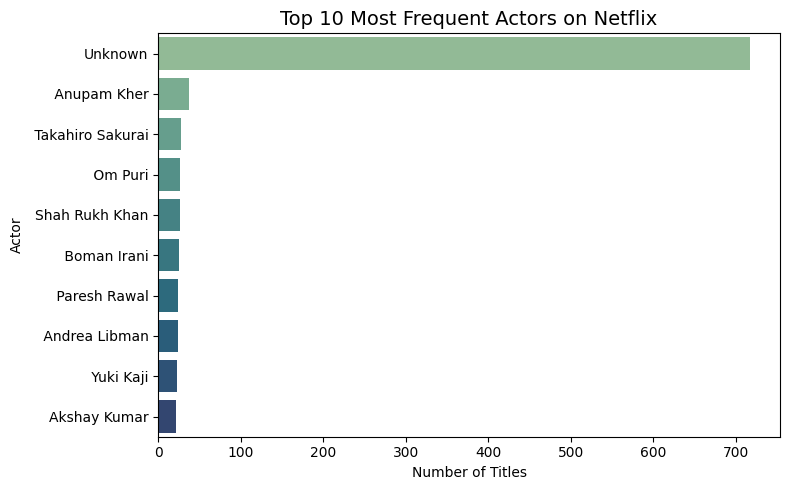

In [12]:
top_directors = df['Director'].value_counts().head(10)
top_cast = df['Cast'].str.split(',').explode().value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_directors.values, y=top_directors.index, palette='rocket')
plt.title("Top 10 Directors on Netflix", fontsize=14)
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x=top_cast.values, y=top_cast.index, palette='crest')
plt.title("Top 10 Most Frequent Actors on Netflix", fontsize=14)
plt.xlabel("Number of Titles")
plt.ylabel("Actor")
plt.tight_layout()
plt.show()

Step 10: Summary Insights

In [13]:
print("\n===== Summary Insights =====")
print("1️⃣ Movies vs TV Shows Distribution:")
print(df['Category'].value_counts(), "\n")

print("2️⃣ Top 5 Countries with Most Content:")
print(top_countries.head(5), "\n")

print("3️⃣ Most Common Ratings on Netflix:")
print(df['Rating'].value_counts().head(5), "\n")

print("4️⃣ Average Movie Duration:")
print(df[df['Duration_Type'] == 'min']['Duration_Val'].mean(), "minutes\n")


===== Summary Insights =====
1️⃣ Movies vs TV Shows Distribution:
Category
Movie      5379
TV Show    2410
Name: count, dtype: int64 

2️⃣ Top 5 Countries with Most Content:
Country
United States     3298
India              990
United Kingdom     723
Unknown            507
Canada             412
Name: count, dtype: int64 

3️⃣ Most Common Ratings on Netflix:
Rating
TV-MA    2865
TV-14    1931
TV-PG     806
R         665
PG-13     386
Name: count, dtype: int64 

4️⃣ Average Movie Duration:
99.3065625580963 minutes



Step 11: Strategic Recommendations


In [14]:
print("===== Strategic Recommendations =====")
print("- Focus more on top-performing countries such as", ', '.join(top_countries.head(5).index))
print("- Maintain a balance between Movies and TV Shows to capture diverse audiences.")
print("- Increase local content production in emerging markets.")
print("- Expand in underrepresented genres and languages to attract new viewers.")
print("- Continue leveraging high-performing directors and actors for Originals.")

===== Strategic Recommendations =====
- Focus more on top-performing countries such as United States, India, United Kingdom, Unknown, Canada
- Maintain a balance between Movies and TV Shows to capture diverse audiences.
- Increase local content production in emerging markets.
- Expand in underrepresented genres and languages to attract new viewers.
- Continue leveraging high-performing directors and actors for Originals.
